<a target="_blank" href="https://colab.research.google.com/github/NovaVolunteer/vscode/blob/main/dat_viz_nbs.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Set up environment

In [1]:
import pandas as pd #data manipulation
import numpy as np #arrays & math
import matplotlib.pyplot as plt #data visualization
import seaborn as sns #statistical visualization
from scipy.stats import gaussian_kde #scientific computing
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
# read in the data
url = "https://github.com/UVADS/DS-3021/raw/refs/heads/main/data/NBA_Perf_22.csv"

df = pd.read_csv(url, encoding='latin-1')

In [5]:
## check the data

df.head(10)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Precious Achiuwa,C,22,TOR,73,28,23.6,3.6,8.3,0.439,...,0.595,2.0,4.5,6.5,1.1,0.5,0.6,1.2,2.1,9.1
1,Steven Adams,C,28,MEM,76,75,26.3,2.8,5.1,0.547,...,0.543,4.6,5.4,10.0,3.4,0.9,0.8,1.5,2.0,6.9
2,Bam Adebayo,C,24,MIA,56,56,32.6,7.3,13.0,0.557,...,0.753,2.4,7.6,10.1,3.4,1.4,0.8,2.6,3.1,19.1
3,Santi Aldama,PF,21,MEM,32,0,11.3,1.7,4.1,0.402,...,0.625,1.0,1.7,2.7,0.7,0.2,0.3,0.5,1.1,4.1
4,LaMarcus Aldridge,C,36,BRK,47,12,22.3,5.4,9.7,0.550,...,0.873,1.6,3.9,5.5,0.9,0.3,1.0,0.9,1.7,12.9
5,Nickeil Alexander-Walker,SG,23,TOT,65,21,22.6,3.9,10.5,0.372,...,0.743,0.6,2.3,2.9,2.4,0.7,0.4,1.4,1.6,10.6
6,Nickeil Alexander-Walker,SG,23,NOP,50,19,26.3,4.7,12.6,0.375,...,0.722,0.7,2.6,3.3,2.8,0.8,0.4,1.7,1.8,12.8
7,Nickeil Alexander-Walker,SG,23,UTA,15,2,9.9,1.1,3.2,0.333,...,0.917,0.1,1.5,1.5,1.1,0.3,0.3,0.5,1.0,3.5
8,Grayson Allen,SG,26,MIL,66,61,27.3,3.9,8.6,0.448,...,0.865,0.5,2.9,3.4,1.5,0.7,0.3,0.7,1.5,11.1
9,Jarrett Allen,C,23,CLE,56,56,32.3,6.6,9.7,0.677,...,0.708,3.4,7.3,10.8,1.6,0.8,1.3,1.7,1.7,16.1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  812 non-null    object 
 1   Pos     812 non-null    object 
 2   Age     812 non-null    int64  
 3   Tm      812 non-null    object 
 4   G       812 non-null    int64  
 5   GS      812 non-null    int64  
 6   MP      812 non-null    float64
 7   FG      812 non-null    float64
 8   FGA     812 non-null    float64
 9   FG%     797 non-null    float64
 10  3P      812 non-null    float64
 11  3PA     812 non-null    float64
 12  3P%     740 non-null    float64
 13  2P      812 non-null    float64
 14  2PA     812 non-null    float64
 15  2P%     784 non-null    float64
 16  eFG%    797 non-null    float64
 17  FT      812 non-null    float64
 18  FTA     812 non-null    float64
 19  FT%     715 non-null    float64
 20  ORB     812 non-null    float64
 21  DRB     812 non-null    float64
 22  TR

In [7]:
df.describe() # Use this to get a quick summary of the data. It will give you the count, mean,
# standard deviation, min, max, and quartiles for each numeric column in the DataFrame.


,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
count,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,797.000000,812.000000,812.000000,740.000000,...,715.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000
mean,26.051724,36.705665,16.672414,18.264655,2.869828,6.386330,0.434257,0.871305,2.560591,0.303445,...,0.747571,0.812808,2.519704,3.331527,1.808251,0.582759,0.353448,0.978695,1.564532,7.812192
std,4.059640,25.898042,23.817195,9.649056,2.224084,4.651322,0.137794,0.841935,2.205642,0.138111,...,0.156305,0.744173,1.790751,2.352880,1.838080,0.425452,0.360744,0.817941,0.826830,6.138266
min,19.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,12.000000,0.000000,10.500000,1.200000,3.000000,0.385000,0.200000,0.800000,0.258750,...,0.673500,0.300000,1.300000,1.700000,0.500000,0.300000,0.100000,0.400000,1.000000,3.300000
50%,25.000000,36.500000,4.000000,17.500000,2.400000,5.150000,0.441000,0.700000,2.050000,0.331000,...,0.765000,0.600000,2.300000,2.900000,1.200000,0.500000,0.300000,0.800000,1.600000,6.300000
75%,29.000000,61.000000,25.000000,25.725000,3.900000,8.725000,0.500000,1.400000,3.900000,0.376250,...,0.846000,1.100000,3.400000,4.400000,2.400000,0.900000,0.500000,1.300000,2.200000,10.600000
max,41.000000,82.000000,82.000000,43.500000,11.400000,21.800000,1.000000,4.500000,11.700000,1.000000,...,1.000000,4.600000,11.000000,14.700000,10.800000,2.500000,2.800000,4.800000,5.000000,30.600000


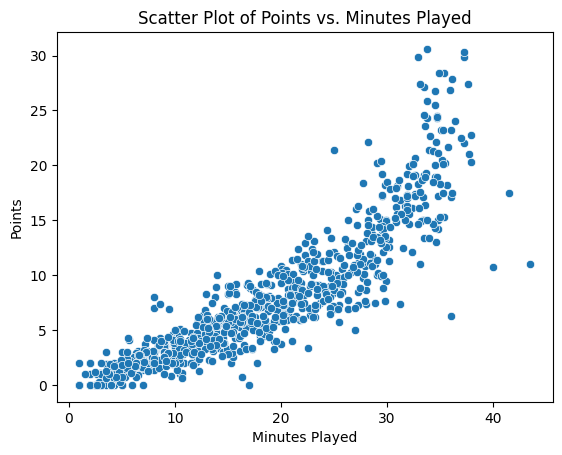

In [8]:
# generate a scatter plot to visualize the relationship between two numeric variables, for example, 'Points' and 'Minutes Played'
sns.scatterplot(data=df, x='MP', y='PTS')
plt.title('Scatter Plot of Points vs. Minutes Played')
plt.xlabel('Minutes Played')
plt.ylabel('Points')
plt.show()


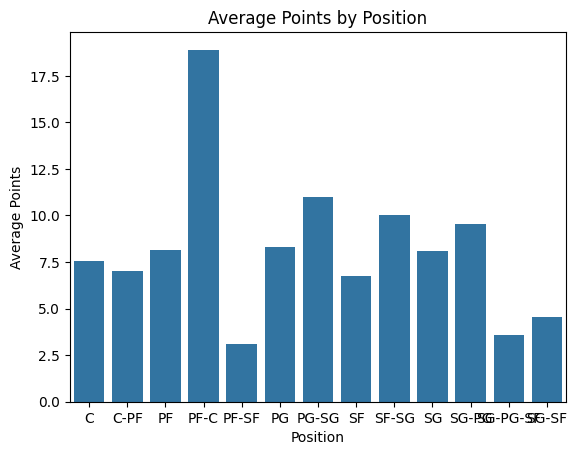

In [9]:
# Let's create a bar chart to show the average points scored by players in different positions.
# We will group the data by 'Pos' and calculate the mean of 'PTS' for each position.

avg_points_by_position = df.groupby('Pos')['PTS'].mean().reset_index() # This groups the data by 'Pos', calculates the mean of 'PTS' for each group,
#and resets the index to get a DataFrame. Indexing by 'Pos' allows us to easily plot the average points for each position.

sns.barplot(data=avg_points_by_position, x='Pos', y='PTS') # This creates a bar plot with 'Pos' on the x-axis and the average 'PTS' on the y-axis.

plt.title('Average Points by Position') # All labels and titles
plt.xlabel('Position')
plt.ylabel('Average Points')
plt.show()

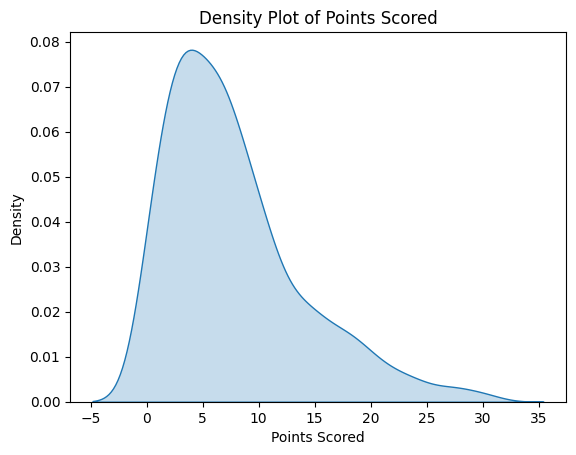

In [ ]:
# Create a density plot to visualize the distribution of points scored by players.
sns.kdeplot(data=df, x='PTS', fill=True) # This creates a kernel density estimate plot for the 'PTS' column,
# which shows the distribution of points scored by players.
plt.title('Density Plot of Points Scored') # All labels and titles
plt.xlabel('Points Scored')
plt.ylabel('Density')
plt.show()

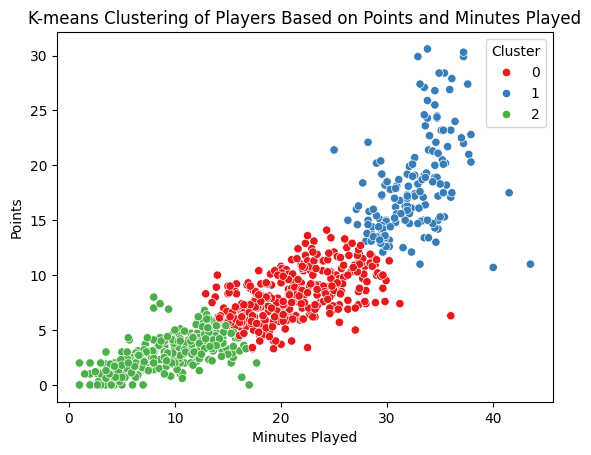

In [10]:
# We can use modeling to better understand the patterns of player performance and make predictions about future performance.
# For example, we could use K-means clustering to group players based on their performance metrics, or we could use linear regression to predict a player's points based on their minutes played and other factors.
# Let's build a k-means clustering model to group players based on their points and minutes played.

#Build a model
scaler = StandardScaler()
kmeans = KMeans(n_clusters=3)
kmeans.fit(scaler.fit_transform(df[['MP', 'PTS']]))
df['Cluster'] = kmeans.labels_

#Visualize the clusters
sns.scatterplot(data=df, x='MP', y='PTS', hue='Cluster', palette='Set1')
plt.title('K-means Clustering of Players Based on Points and Minutes Played')
plt.xlabel('Minutes Played')
plt.ylabel('Points')
plt.legend(title='Cluster')
plt.show()

